In [1]:
# ============================================
# SEMANA 12 - AUTOTEC
# Algoritmos Supervisados: Clasificacion
# Predecir grupo de depreciacion
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from builtins import round as py_round

# ============================================
# CARGAR DATOS ETIQUETADOS DE SEMANA 10
# ============================================

ruta_datos = "/home/jovyan/work/autotec/semana10_final/modelos/datos_etiquetados_kmeans.csv"
df_clusters = pd.read_csv(ruta_datos)

print(f"Total de registros: {len(df_clusters)}")
print(f"\nDistribucion de grupos de depreciacion:")
print(df_clusters["grupo_depreciacion"].value_counts())

df_clusters[["marca", "precio", "kilometraje", "depreciacion_estimada", "prediction", "grupo_depreciacion"]].head(10)

Total de registros: 1955

Distribucion de grupos de depreciacion:
grupo_depreciacion
Depreciacion Media    1125
Depreciacion Alta      631
Depreciacion Baja      199
Name: count, dtype: int64


,marca,precio,kilometraje,depreciacion_estimada,prediction,grupo_depreciacion
0,audi,22990000.0,27294.0,842.278806,0,Depreciacion Media
1,audi,22990000.0,11766.0,1953.769015,0,Depreciacion Media
2,audi,23990000.0,1077.0,22254.174397,2,Depreciacion Baja
3,audi,12950000.0,115092.0,112.517703,1,Depreciacion Alta
4,audi,18990000.0,84917.0,223.627499,0,Depreciacion Media
5,audi,23790000.0,26235.0,906.769325,0,Depreciacion Media
6,audi,36990000.0,29450.0,1255.984517,2,Depreciacion Baja
7,audi,54990000.0,1500.0,36635.576282,2,Depreciacion Baja
8,audi,12970000.0,182000.0,71.263345,1,Depreciacion Alta
9,audi,57990000.0,10808.0,5364.973633,2,Depreciacion Baja


In [2]:
# ============================================
# PREPARACION PARA CLASIFICACION
# Renombramos 'prediction' a 'label'
# ============================================

df_supervisado = df_clusters.copy()
df_supervisado = df_supervisado.rename(columns={"prediction": "label"})

# Features para clasificacion
feature_cols = [
    "scaledFeatures_0",  # precio escalado
    "scaledFeatures_1",  # kilometraje escalado
    "scaledFeatures_2",  # year escalado
    "scaledFeatures_3",  # depreciacion_estimada escalada
    "scaledFeatures_4",  # marca_cat escalado
    "scaledFeatures_5"   # combustible_cat escalado
]

X = df_supervisado[feature_cols].dropna()
y = df_supervisado.loc[X.index, "label"]

# Dividimos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Datos de entrenamiento: {len(X_train)}")
print(f"Datos de prueba:        {len(X_test)}")

Datos de entrenamiento: 1368
Datos de prueba:        587


In [4]:
# ============================================
# ARBOL DE DECISION
# ============================================

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("=== ARBOL DE DECISION ===")
comparativa_dt = pd.DataFrame({
    "marca":      df_supervisado.loc[X_test.index, "marca"].values,
    "label":      y_test.values,
    "prediction": y_pred_dt
})
print(comparativa_dt.head(10).to_string(index=False))
print(f"\nPrecisión Arbol de decision: {py_round(accuracy_score(y_test, y_pred_dt) * 100, 2)}%")

=== ARBOL DE DECISION ===
   marca  label  prediction
mercedes      1           1
 peugeot      0           0
     kia      0           0
  toyota      0           0
      mg      0           0
  toyota      1           1
    jeep      0           0
 hyundai      1           1
mercedes      1           1
      mg      1           1

Precisión Arbol de decision: 90.63%


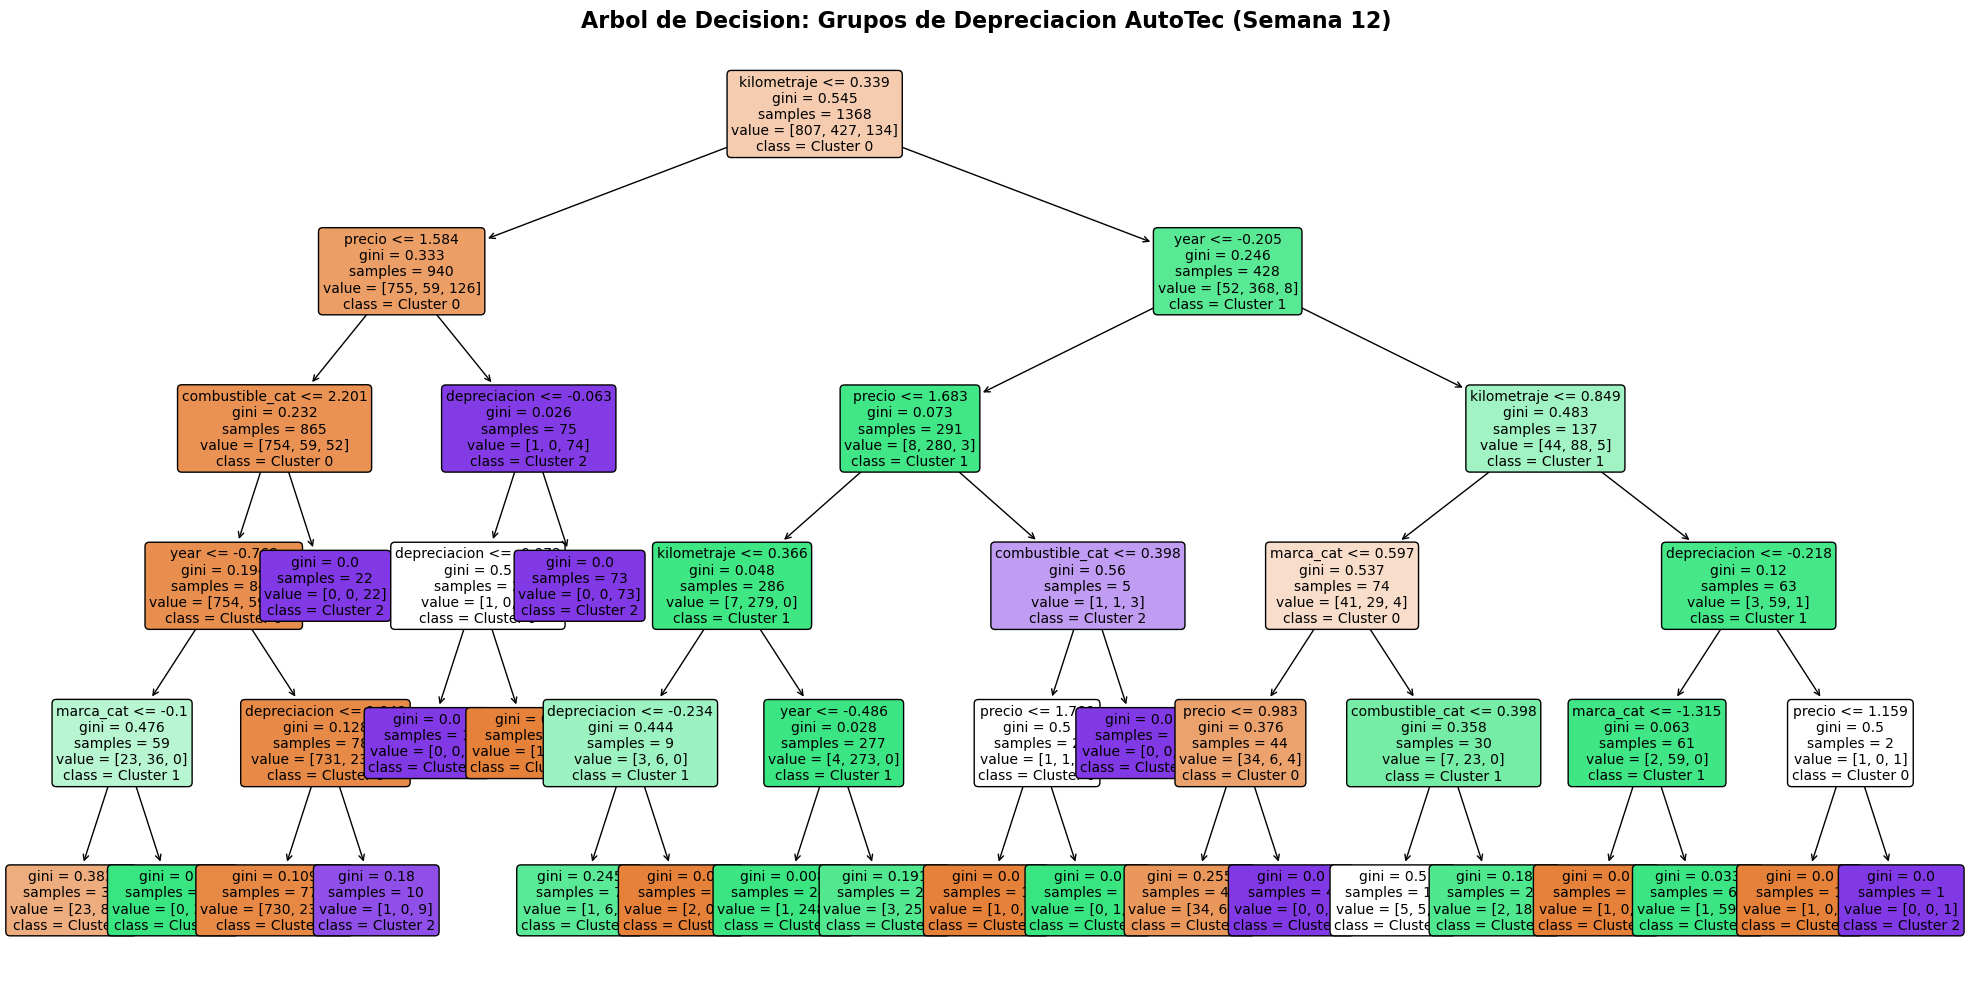

Grafico guardado: arbol_decision_depreciacion.png


In [5]:
# ============================================
# VISUALIZACION DEL ARBOL DE DECISION
# ============================================

nombres_features = ["precio", "kilometraje", "year", "depreciacion", "marca_cat", "combustible_cat"]
nombres_clases   = [f"Cluster {int(c)}" for c in sorted(y.unique())]

plt.figure(figsize=(20, 10), dpi=100)
plot_tree(
    dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Arbol de Decision: Grupos de Depreciacion AutoTec (Semana 12)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("arbol_decision_depreciacion.png", dpi=150)
plt.show()
print("Grafico guardado: arbol_decision_depreciacion.png")

In [7]:
# ============================================
# RANDOM FOREST + SVM + REGRESION LOGISTICA
# ============================================

# MODELO 1: Random Forest
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# MODELO 2: SVM (OneVsRest para multiclase)
svm_binario = LinearSVC(max_iter=1000, random_state=42, dual="auto")
ovr_svm     = OneVsRestClassifier(svm_binario)
ovr_svm.fit(X_train, y_train)
y_pred_svm  = ovr_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# MODELO 3: Regresion Logistica Multinomial
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class="multinomial")
lr.fit(X_train, y_train)
y_pred_lr   = lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("=" * 50)
print("  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  ")
print("=" * 50)
print(f"1. Random Forest Accuracy:       {py_round(accuracy_rf  * 100, 2)}%")
print(f"2. SVM (OneVsRest) Accuracy:     {py_round(accuracy_svm * 100, 2)}%")
print(f"3. Regresion Logistica Accuracy: {py_round(accuracy_lr  * 100, 2)}%")
print("=" * 50)

  RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 12)  
1. Random Forest Accuracy:       95.91%
2. SVM (OneVsRest) Accuracy:     98.64%
3. Regresion Logistica Accuracy: 99.49%


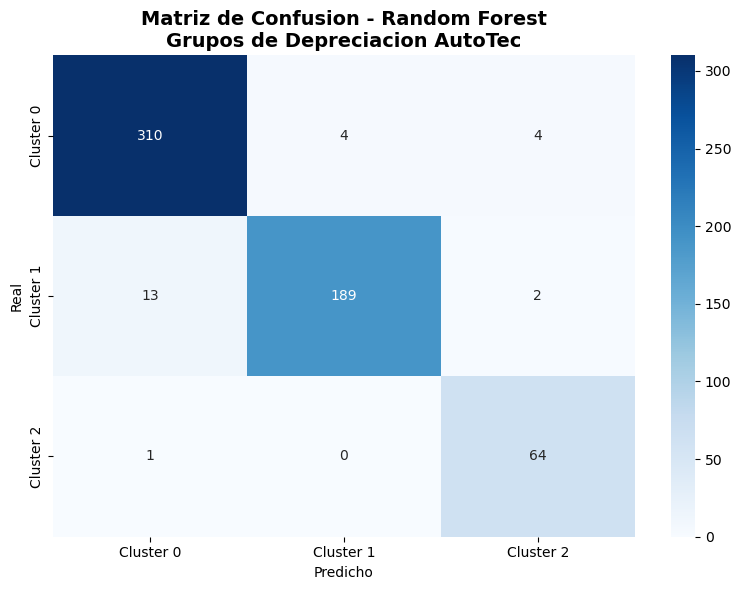

Grafico guardado: confusion_matrix_depreciacion.png


In [8]:
# ============================================
# GRAFICO: MATRIZ DE CONFUSION RANDOM FOREST
# ============================================

cm = confusion_matrix(y_test, y_pred_rf)
etiquetas = ["Cluster 0", "Cluster 1", "Cluster 2"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    cmap="Blues",
    xticklabels=etiquetas,
    yticklabels=etiquetas
)
plt.title("Matriz de Confusion - Random Forest\nGrupos de Depreciacion AutoTec", fontsize=14, fontweight="bold")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrix_depreciacion.png", dpi=150)
plt.show()
print("Grafico guardado: confusion_matrix_depreciacion.png")

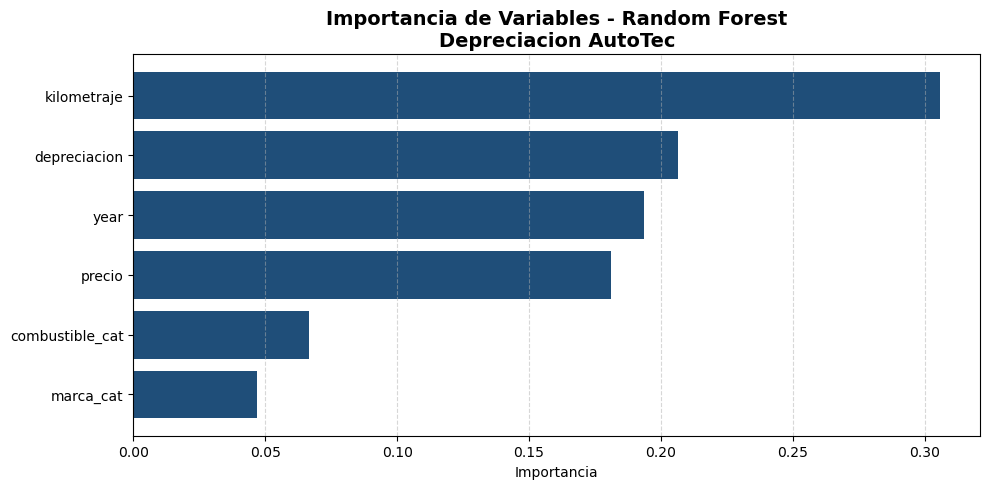

Grafico guardado: importancia_variables_depreciacion.png

Clasificacion completada correctamente.


In [9]:
# ============================================
# GRAFICO: IMPORTANCIA DE VARIABLES
# Random Forest
# ============================================

importancias = rf.feature_importances_
imp_df = pd.DataFrame({
    "variable":    nombres_features,
    "importancia": importancias
}).sort_values("importancia", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(imp_df["variable"], imp_df["importancia"], color="#1f4e79")
plt.title("Importancia de Variables - Random Forest\nDepreciacion AutoTec", fontsize=14, fontweight="bold")
plt.xlabel("Importancia")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("importancia_variables_depreciacion.png", dpi=150)
plt.show()
print("Grafico guardado: importancia_variables_depreciacion.png")

print("\nClasificacion completada correctamente.")